<a href="https://colab.research.google.com/github/raki-rankawat/stm32-mobilenet/blob/main/VWW_VGG_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =====================================================
# Imports
# =====================================================

import os
import time
import tarfile
import random
import shutil
from pathlib import Path
from urllib.request import urlretrieve
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# =====================================================
# Device Setup
# =====================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(41)

In [4]:
# =====================================================
# Auto Download + Prepare VWW (10k subset)
# =====================================================

vww_url = "https://www.silabs.com/public/files/github/machine_learning/benchmarks/datasets/vw_coco2014_96.tar.gz"

base_dir = Path("/content/vww_work")
archive_path = base_dir / "vw_coco2014_96.tar.gz"
extract_dir = base_dir / "extracted"
subset_dir = base_dir / "vww_10k"

# Subset config: 5k person + 5k non_person
n_per_class = 5000
val_ratio = 0.20

random.seed(41)
torch.manual_seed(41)

def download_vww():
    base_dir.mkdir(parents=True, exist_ok=True)

    if archive_path.exists() and archive_path.stat().st_size > 0:
        print("✅ VWW archive already downloaded")
        return

    print("⬇️ Downloading VWW archive...")
    urlretrieve(vww_url, archive_path)
    print("✅ Download complete:", archive_path)

def extract_vww():
    extract_dir.mkdir(parents=True, exist_ok=True)

    if any(extract_dir.iterdir()):
        print("✅ VWW already extracted")
        return

    print("📦 Extracting VWW archive...")
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(extract_dir)
    print("✅ Extraction complete:", extract_dir)

def find_vww_root():
    # Find folder that contains BOTH person/ and non_person/
    for p in extract_dir.rglob("person"):
        if p.is_dir() and (p.parent / "non_person").is_dir():
            return p.parent
    raise RuntimeError("❌ Could not find 'person' and 'non_person' directories under extracted dataset")

def list_images(folder):
    exts = {".jpg", ".jpeg", ".png"}
    return [p for p in folder.rglob("*") if p.is_file() and p.suffix.lower() in exts]

def make_vww_subset(src_root):
    # Skip if subset already exists
    if (subset_dir / "train" / "person").is_dir() and (subset_dir / "val" / "non_person").is_dir():
        print("✅ VWW 10k subset already exists:", subset_dir)
        return

    for split in ["train", "val"]:
        for c in ["person", "non_person"]:
            (subset_dir / split / c).mkdir(parents=True, exist_ok=True)

    person_imgs = list_images(src_root / "person")
    nonperson_imgs = list_images(src_root / "non_person")

    if len(person_imgs) < n_per_class or len(nonperson_imgs) < n_per_class:
        raise ValueError(
            f"❌ Not enough images:\n"
            f"person: {len(person_imgs)} (need {n_per_class})\n"
            f"non_person: {len(nonperson_imgs)} (need {n_per_class})"
        )

    random.shuffle(person_imgs)
    random.shuffle(nonperson_imgs)

    person_sel = person_imgs[:n_per_class]
    nonperson_sel = nonperson_imgs[:n_per_class]

    def split_list(lst, val_ratio):
        n_val = int(len(lst) * val_ratio)
        return lst[n_val:], lst[:n_val]  # train, val

    p_train, p_val = split_list(person_sel, val_ratio)
    n_train, n_val = split_list(nonperson_sel, val_ratio)

    def copy_files(files, dst_dir):
        for f in files:
            dst = dst_dir / f.name
            # avoid rare collisions
            if dst.exists():
                dst = dst_dir / (f"{f.parent.name}_{f.name}")
            shutil.copy2(f, dst)

    print("🧩 Creating VWW 10k subset...")
    copy_files(p_train, subset_dir / "train" / "person")
    copy_files(p_val,   subset_dir / "val"   / "person")
    copy_files(n_train, subset_dir / "train" / "non_person")
    copy_files(n_val,   subset_dir / "val"   / "non_person")
    print("✅ VWW subset created at:", subset_dir)

download_vww()
extract_vww()
vww_root = find_vww_root()
print("✅ Found VWW root:", vww_root)
make_vww_subset(vww_root)

⬇️ Downloading VWW archive...
✅ Download complete: /content/vww_work/vw_coco2014_96.tar.gz
📦 Extracting VWW archive...


/tmp/ipykernel_603/1742570258.py:39: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_dir)


✅ Extraction complete: /content/vww_work/extracted
✅ Found VWW root: /content/vww_work/extracted/vw_coco2014_96
🧩 Creating VWW 10k subset...
✅ VWW subset created at: /content/vww_work/vww_10k


In [5]:
# =====================================================
# Data Loaders
# =====================================================
batch_size = 64
img_size = 96

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(96, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3
    ),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.485, 0.456, 0.406),
        (0.229, 0.224, 0.225)
    )
])

test_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

train_data = datasets.ImageFolder(root=str(subset_dir / "train"), transform=train_transform)
test_data  = datasets.ImageFolder(root=str(subset_dir / "val"),   transform=test_transform)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=batch_size, shuffle=False)

print("Class mapping:", train_data.class_to_idx)

Class mapping: {'non_person': 0, 'person': 1}


In [6]:
# =====================================================
# VGG-Style CNN for VWW
# =====================================================

class VWW_VGGStyle(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 96 → 48

            # Block 2
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 48 → 24

            # Block 3
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 24 → 12

            # Block 4
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.Conv2d(512, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 12 → 6
        )

        self.avgpool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

In [7]:
# =====================================================
# Model Initialization
# =====================================================

model = VWW_VGGStyle().to(device)

In [8]:
# =====================================================
# Loss, Optimizers & Scheduler
# =====================================================

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Learning rate decay every 20 epochs
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

In [9]:
# =====================================================
# Training Function
# =====================================================

def train(model, loader, criterion, optimizer, device):
    model.train()

    correct = 0
    total = 0
    running_loss = 0

    for X, y in loader:
        X = X.to(device)
        y = y.to(device)

        outputs = model(X)
        loss = criterion(outputs, y)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        batch_size = y.size(0)
        running_loss += loss.item() * batch_size

        preds = outputs.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += batch_size

    return running_loss / total, correct / total

In [10]:
# =====================================================
# Testing Function
# =====================================================

def test(model, loader, criterion):
    model.eval()

    correct = 0
    total = 0
    running_loss = 0

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            y = y.to(device)

            outputs = model(X)
            loss = criterion(outputs, y)

            batch_size = y.size(0)
            running_loss += loss.item() * batch_size

            preds = outputs.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += batch_size

    return running_loss / total, correct / total

In [11]:
# =====================================================
# Training Loop
# =====================================================

epochs = 50
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

best_acc = 0.0
best_epoch = 1
patience = 8
patience_counter = 0

start_time = time.time()

best_path = "/content/drive/My Drive/Colab Notebooks/vww_vgg_model.pth"

for epoch in range(1, epochs + 1):

    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = test(model, test_loader, criterion)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    # Step scheduler
    scheduler.step()

    print(
        f"Epoch: {epoch}/{epochs} | "
        f"LR: {scheduler.get_last_lr()[0]:.6f} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc * 100:.2f}% | "
        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc * 100:.2f}%"
    )

    if test_acc > best_acc:
        best_acc = test_acc
        best_epoch = epoch
        patience_counter = 0
        torch.save(model.state_dict(), best_path)
        print("✅ Model saved as vww_vgg_model.pth for epoch", best_epoch)
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("🛑 Early stopping at epoch", epoch, "| Best epoch:", best_epoch, "| Best Test Acc:", f"{best_acc*100:.2f}%")
        break

print(f"Training Time: {(time.time() - start_time) / 60} minutes!")
print("Best epoch:", best_epoch, "| Best Test Acc:", f"{best_acc*100:.2f}%")

Epoch: 1/50 | LR: 0.000999 | Train Loss: 0.6929 | Train Acc: 56.83% | Test Loss: 0.6792 | Test Acc: 61.40%
✅ Model saved as vww_vgg_model.pth for epoch 1
Epoch: 2/50 | LR: 0.000996 | Train Loss: 0.6733 | Train Acc: 60.22% | Test Loss: 0.6486 | Test Acc: 64.90%
✅ Model saved as vww_vgg_model.pth for epoch 2
Epoch: 3/50 | LR: 0.000991 | Train Loss: 0.6634 | Train Acc: 61.42% | Test Loss: 0.6500 | Test Acc: 62.65%
Epoch: 4/50 | LR: 0.000984 | Train Loss: 0.6581 | Train Acc: 62.79% | Test Loss: 0.6377 | Test Acc: 67.55%
✅ Model saved as vww_vgg_model.pth for epoch 4
Epoch: 5/50 | LR: 0.000976 | Train Loss: 0.6512 | Train Acc: 64.20% | Test Loss: 0.6334 | Test Acc: 66.90%
Epoch: 6/50 | LR: 0.000965 | Train Loss: 0.6475 | Train Acc: 64.89% | Test Loss: 0.6219 | Test Acc: 67.90%
✅ Model saved as vww_vgg_model.pth for epoch 6
Epoch: 7/50 | LR: 0.000952 | Train Loss: 0.6393 | Train Acc: 65.36% | Test Loss: 0.6078 | Test Acc: 70.35%
✅ Model saved as vww_vgg_model.pth for epoch 7
Epoch: 8/50 | LR

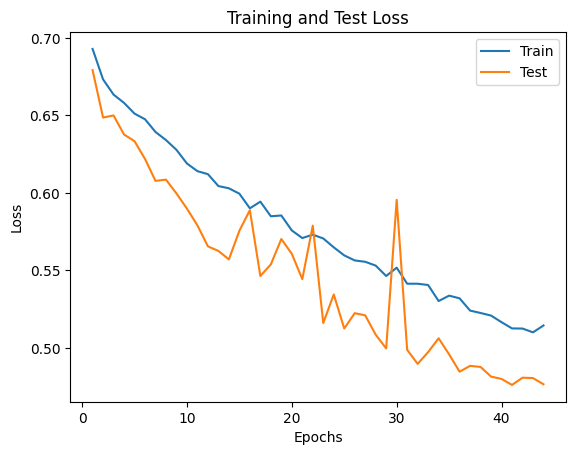

In [12]:
# =====================================================
# Loss Plot
# =====================================================

plt.figure()
plt.plot(range(1, len(train_losses) + 1), train_losses)
plt.plot(range(1, len(test_losses) + 1), test_losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend(["Train", "Test"])
plt.show()

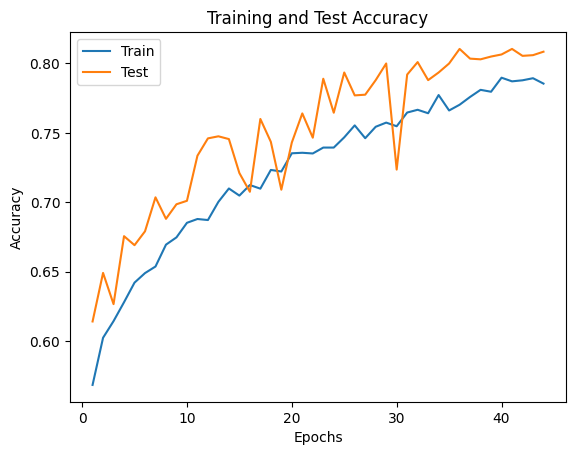

In [13]:
# =====================================================
# Accuracy Plot
# =====================================================

plt.figure()
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies)
plt.plot(range(1, len(test_accuracies) + 1), test_accuracies)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy")
plt.legend(["Train", "Test"])
plt.show()

In [14]:
# =====================================================
# Denormalize Images
# =====================================================

def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return img * std + mean

In [15]:
# =====================================================
# Show Specific CIFAR Test Images (One Row)
# =====================================================

classes = train_data.classes

def show_specific_images(indices):

    model.eval()
    num_images = len(indices)

    plt.figure(figsize=(3 * num_images, 3))

    for i, idx in enumerate(indices):

        image, label = test_data[idx]

        # Keep original normalized tensor for inference
        input_tensor = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            probabilities = F.softmax(output, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

        # Denormalize only for display
        image_display = denormalize(image).clamp(0, 1)

        plt.subplot(1, num_images, i + 1)
        plt.imshow(image_display.permute(1, 2, 0).cpu())

        correct = predicted.item() == label
        color = "green" if correct else "red"

        plt.title(
            f"P: {classes[predicted.item()]}\n"
            f"T: {classes[label]}\n"
            f"{confidence.item()*100:.1f}%",
            color=color
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

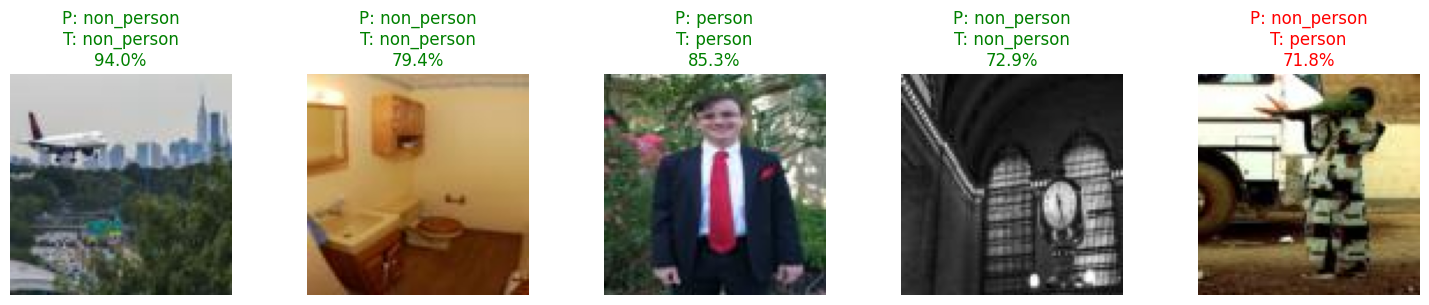

In [16]:
show_specific_images([500, 303, 1011, 999, 1001])

In [17]:
# =====================================================
# Show Random Test Predictions (One Row)
# =====================================================

classes = train_data.classes

def show_random_predictions(num_images=5):

    model.eval()
    indices = random.sample(range(len(test_data)), num_images)

    plt.figure(figsize=(3 * num_images, 3))

    for i, idx in enumerate(indices):

        image, label = test_data[idx]

        # Keep normalized image for inference
        input_tensor = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            probabilities = F.softmax(output, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

        # Denormalize only for visualization
        image_display = denormalize(image).clamp(0, 1)

        plt.subplot(1, num_images, i + 1)
        plt.imshow(image_display.permute(1, 2, 0).cpu())

        correct = predicted.item() == label
        color = "green" if correct else "red"

        plt.title(
            f"P: {classes[predicted.item()]}\n"
            f"T: {classes[label]}\n"
            f"{confidence.item()*100:.1f}%",
            color=color
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

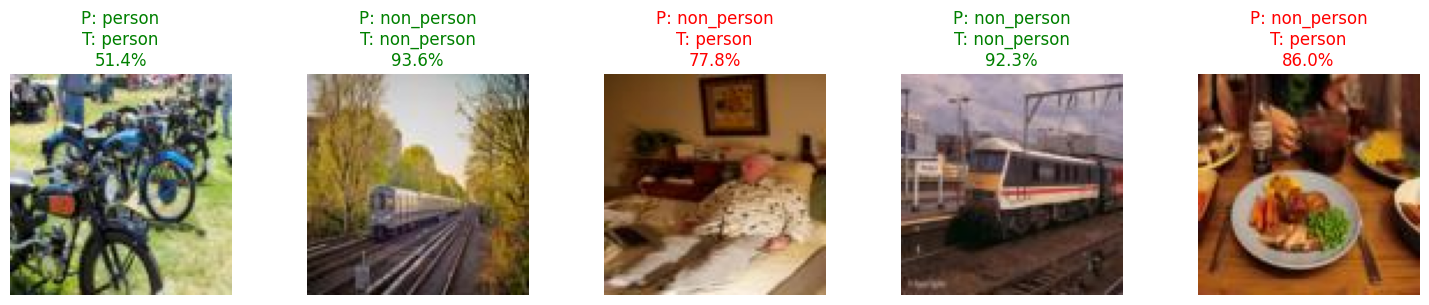

In [18]:
show_random_predictions(5)